# PUMA Dataset Radiomics Analysis

This notebook analyzes radiomics features extracted from the PUMA (Panoptic segmentation of nuclei and tissues in pathology images for melanoma) dataset.

**Dataset**: PUMA Grand Challenge - https://puma.grand-challenge.org/

**Contents**:
1. Data Download Instructions & Setup
2. Cell-level Radiomics Analysis (Detections)
3. Tissue-level Radiomics Analysis (Annotations)
4. Comparative Summary


In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

radiomics_dir = "/Users/tamara/Desktop/PyRadiomics/Qupath/radiomics"
output_dir = "/Users/tamara/Desktop/PyRadiomics/QuRad/article_figures"
os.makedirs(output_dir, exist_ok=True)

date_prefer = "20260127"

file_pattern = "training_set_*_roi_*_tif_radiomics_*.csv"

correlation_threshold = 0.90
n_top_features = 70


In [2]:
def _drop_constant_cols(df: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    """Drop columns with zero or near-zero variance."""
    nunique = df.nunique(dropna=True)
    keep = nunique[nunique > 1].index
    df = df[keep]
    var = df.var(axis=0, ddof=0)
    return df.loc[:, var.fillna(0.0) > eps]

def prune_correlated_features(df: pd.DataFrame, threshold: float = 0.90) -> tuple[pd.DataFrame, list[str]]:
    """Greedy correlation pruning; returns (kept_df, dropped_cols)."""
    if df.shape[1] <= 1:
        return df, []
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop: set[str] = set()
    mean_corr = corr.mean(axis=0)
    for col in upper.columns:
        hits = upper.index[upper[col] > threshold].tolist()
        for row in hits:
            if row in to_drop or col in to_drop:
                continue
            drop = col if mean_corr[col] >= mean_corr[row] else row
            to_drop.add(drop)
    kept = [c for c in df.columns if c not in to_drop]
    return df[kept], sorted(to_drop)

def compute_feature_importance(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """Compute feature importance using MI, ANOVA, and RF."""
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_filled = X.fillna(X.median())
    
    results = pd.DataFrame(index=X.columns)
    
    # Mutual Information
    mi_scores = mutual_info_classif(X_filled, y_enc, random_state=0, n_neighbors=5)
    results['MutualInfo'] = mi_scores
    
    # ANOVA F-test
    f_scores, _ = f_classif(X_filled, y_enc)
    results['ANOVA_F'] = np.nan_to_num(f_scores, nan=0)
    
    # Random Forest importance
    rf = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=0, n_jobs=-1)
    rf.fit(X_filled, y_enc)
    results['RF_Importance'] = rf.feature_importances_
    
    # Normalize and compute consensus
    for col in ['MutualInfo', 'ANOVA_F', 'RF_Importance']:
        max_val = results[col].max()
        results[col + '_norm'] = results[col] / max_val if max_val > 0 else 0
    
    norm_cols = [c for c in results.columns if c.endswith('_norm')]
    results['Consensus'] = results[norm_cols].mean(axis=1)
    return results.sort_values('Consensus', ascending=False)

def remap_cell_class(c: str) -> str:
    """Remap cell classes to Tumor / Lymphocyte / Other."""
    c_lower = c.lower()
    if 'tumor' in c_lower:
        return 'Tumor'
    elif 'lymphocyte' in c_lower:
        return 'Lymphocyte'
    else:
        return 'Other'

def tile_id_from_path(p: str):
    """Extract tile ID from file path (PUMA format: training_set_*_roi_XXX_tif_radiomics_*)."""
    basename = os.path.basename(p)

    m = re.search(r"_roi_(\d+)_tif_radiomics", basename)
    if m:
        return int(m.group(1))

    m = re.search(r"img_(\d+)_png_radiomics", basename)
    return int(m.group(1)) if m else None

def date_from_path(p: str):
    """Extract date from file path."""
    m = re.search(r"_radiomics_(20\d{6})_", os.path.basename(p))
    return m.group(1) if m else None

def load_radiomics_data(radiomics_dir, file_pattern, date_prefer=None, object_mode="all"):
    """Load radiomics CSVs, filter by date and object type."""
    all_csv = sorted(glob.glob(os.path.join(radiomics_dir, file_pattern)))
    
    by_date = {}
    for f in all_csv:
        d = date_from_path(f)
        if d:
            by_date.setdefault(d, []).append(f)
    
    use_date = date_prefer if (date_prefer and date_prefer in by_date) else (sorted(by_date.keys())[-1] if by_date else None)
    files = sorted(by_date.get(use_date, [])) if use_date else all_csv
    
    print(f"Using date: {use_date}")
    print(f"Radiomics files: {len(files)}")
    
    if not files:
        raise RuntimeError("No radiomics CSV files found!")
    
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["tile_id"] = tile_id_from_path(f)
        df["source_file"] = os.path.basename(f)
        dfs.append(df)
    
    rad = pd.concat(dfs, ignore_index=True)
    rad["Classification"] = rad["Classification"].fillna("Unclassified")
    
    if "ObjectType" in rad.columns and object_mode != "all":
        ot = rad["ObjectType"].astype(str).str.lower().str.strip()
        if object_mode == "detections":
            rad = rad[ot.isin(["detection", "detections"])].copy()
        elif object_mode == "annotations":
            rad = rad[ot.isin(["annotation", "annotations"])].copy()
    
    return rad, files


## Cell-level Radiomics Analysis (Detections)

Analysis of radiomics features extracted from individual cell nuclei.


In [3]:
rad_cells, files_cells = load_radiomics_data(
    radiomics_dir, file_pattern, date_prefer, object_mode="detections"
)

print(f"\nRows (cells): {rad_cells.shape}")
print(rad_cells["Classification"].value_counts())


Using date: 20260127
Radiomics files: 20

Rows (cells): (8654, 127)
Classification
nuclei_tumor          4131
nuclei_lymphocyte     2057
nuclei_histiocyte     1011
nuclei_stroma          587
nuclei_epithelium      407
nuclei_endothelium     370
nuclei_melanophage      69
nuclei_apoptosis        10
nuclei_plasma_cell       9
nuclei_neutrophil        3
Name: count, dtype: int64


In [4]:
meta_cols = {"Classification", "ClassSimple", "ObjectID", "ObjectType", "tile_id", "source_file"}

rad_cells["ClassSimple"] = rad_cells["Classification"].apply(remap_cell_class)

mask_cells = rad_cells["ClassSimple"].isin(["Tumor", "Lymphocyte"])
rad_cells_filtered = rad_cells[mask_cells].copy()

feat_cols_cells = [c for c in rad_cells_filtered.columns if c not in meta_cols]
X_all_cells = rad_cells_filtered[feat_cols_cells].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
labels_cells = rad_cells_filtered["ClassSimple"].astype(str)
tile_ids_cells = rad_cells_filtered["tile_id"].astype(int)

X_imp_cells = X_all_cells.apply(lambda s: s.fillna(s.median()), axis=0)

X_clean_cells = _drop_constant_cols(X_imp_cells)
X_uncorr_cells, dropped_corr = prune_correlated_features(X_clean_cells, threshold=correlation_threshold)
print(f"\nFeatures: {X_clean_cells.shape[1]} -> {X_uncorr_cells.shape[1]} (removed {len(dropped_corr)} correlated)")


Features: 120 -> 68 (removed 52 correlated)


In [5]:
print("Computing feature importance...")
importance_cells = compute_feature_importance(X_uncorr_cells, labels_cells)

top_features_cells = importance_cells.head(n_top_features).index.tolist()
print(f"\nTop {n_top_features} features by consensus importance:")
for i, f in enumerate(top_features_cells[:10], 1):
    print(f"  {i:2d}. {f}: {importance_cells.loc[f, 'Consensus']:.4f}")

X_final_cells = X_uncorr_cells[top_features_cells].fillna(0)
y_final_cells = labels_cells.reset_index(drop=True)
g_final_cells = tile_ids_cells.reset_index(drop=True)

scaler_cells = StandardScaler()
X_scaled_cells = scaler_cells.fit_transform(X_final_cells)

print(f"\nFinal data: {X_scaled_cells.shape[0]} samples, {X_scaled_cells.shape[1]} features")


Computing feature importance...

Top 70 features by consensus importance:
   1. firstorder_Energy: 0.8774
   2. gldm_DependenceVariance: 0.8171
   3. shape2D_MajorAxisLength: 0.7587
   4. glszm_LargeAreaHighGrayLevelEmphasis: 0.6514
   5. glrlm_RunEntropy: 0.6359
   6. glszm_ZonePercentage: 0.5690
   7. glrlm_GrayLevelNonUniformity: 0.5453
   8. firstorder_Skewness: 0.5299
   9. firstorder_RootMeanSquared: 0.5110
  10. glrlm_LongRunHighGrayLevelEmphasis: 0.4853

Final data: 6188 samples, 68 features


In [6]:
from sklearn.metrics import accuracy_score

n_splits = min(5, g_final_cells.nunique())
cv = GroupKFold(n_splits=n_splits)

print(f"=== Random Forest Classification ===")
print(f"Samples: {len(y_final_cells)} | Features: {X_scaled_cells.shape[1]} | CV folds: {n_splits}")
print(f"Classes: Tumor ({(y_final_cells=='Tumor').sum()}), Lymphocyte ({(y_final_cells=='Lymphocyte').sum()})")

# Random Forest
rf_cells = RandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_split=2,
    class_weight="balanced", random_state=42, n_jobs=-1
)
pred_rf_cells = cross_val_predict(rf_cells, X_scaled_cells, y_final_cells, cv=cv, groups=g_final_cells)

# Metrics
acc = accuracy_score(y_final_cells, pred_rf_cells)
f1_rf_cells = f1_score(y_final_cells, pred_rf_cells, average="macro")

print(f"\nAccuracy: {acc:.3f}")
print(f"Macro F1: {f1_rf_cells:.3f}")
print("\nClassification Report:")
print(classification_report(y_final_cells, pred_rf_cells, zero_division=0))

pred_lookup = {}
for idx in range(len(pred_rf_cells)):
    tile_id = rad_cells_filtered.iloc[idx]["tile_id"]
    obj_id = rad_cells_filtered.iloc[idx]["ObjectID"]
    pred_lookup[(tile_id, obj_id)] = pred_rf_cells[idx]
print(f"\nPrediction lookup created with {len(pred_lookup)} entries")


=== Random Forest Classification ===
Samples: 6188 | Features: 68 | CV folds: 5
Classes: Tumor (4131), Lymphocyte (2057)

Accuracy: 0.872
Macro F1: 0.854

Classification Report:
              precision    recall  f1-score   support

  Lymphocyte       0.82      0.79      0.80      2057
       Tumor       0.90      0.91      0.90      4131

    accuracy                           0.87      6188
   macro avg       0.86      0.85      0.85      6188
weighted avg       0.87      0.87      0.87      6188


Prediction lookup created with 6188 entries


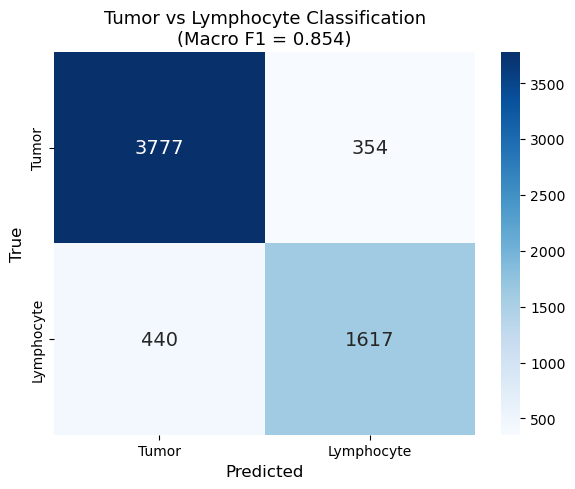

In [7]:
classes_cells = ["Tumor", "Lymphocyte"]

fig, ax = plt.subplots(figsize=(6, 5))

cm_rf = confusion_matrix(y_final_cells, pred_rf_cells, labels=classes_cells)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", 
            xticklabels=classes_cells, yticklabels=classes_cells, ax=ax,
            annot_kws={"size": 14})
ax.set_title(f"Tumor vs Lymphocyte Classification\n(Macro F1 = {f1_rf_cells:.3f})", fontsize=13)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)

plt.tight_layout()
plt.show()


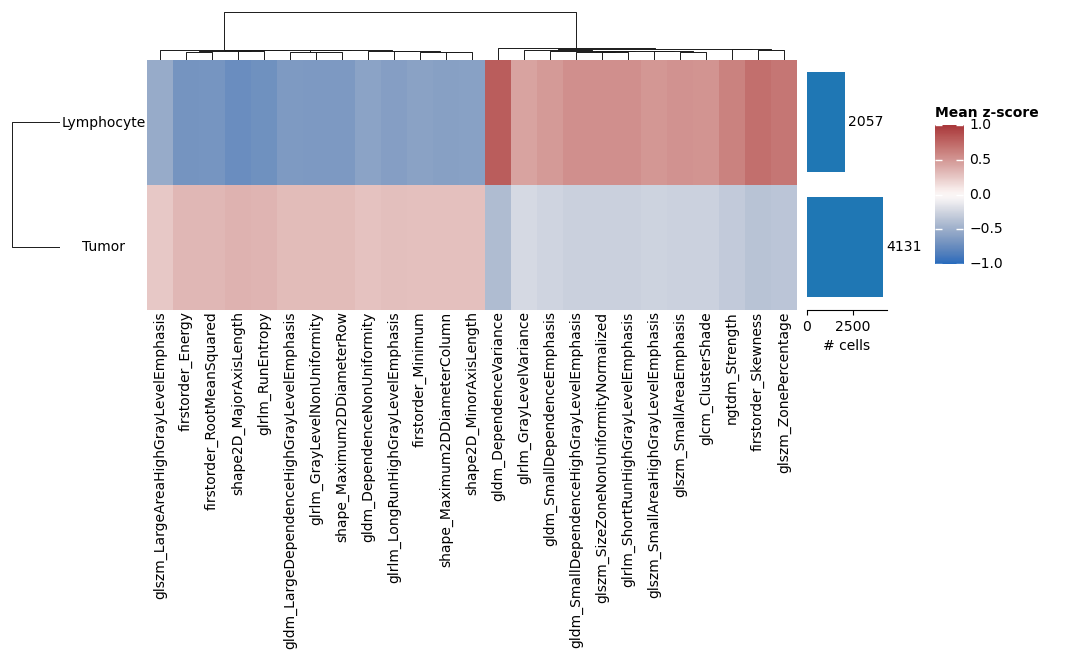

In [8]:
import marsilea as ma
import marsilea.plotter as mp
from matplotlib.colors import TwoSlopeNorm

Xz_cells = pd.DataFrame(X_scaled_cells, columns=top_features_cells)
Xz_cells["Classification"] = y_final_cells.values
means_cells = Xz_cells.groupby("Classification").mean()

mars_feats_cells = means_cells.var(axis=0).sort_values(ascending=False).head(25).index
M_cells = means_cells[mars_feats_cells]

n_cells = y_final_cells.value_counts().reindex(M_cells.index)

h = ma.Heatmap(
    M_cells.to_numpy(),
    cmap="vlag",
    norm=TwoSlopeNorm(vcenter=0),
    width=6.5,
    height=2.5,
    label="Mean z-score",
)

h.add_left(mp.Labels(M_cells.index.tolist(), align="center"))
h.add_bottom(mp.Labels(M_cells.columns.tolist(), rotation=90))
h.add_right(mp.Numbers(n_cells.values, label="# cells"), pad=0.1, size=0.8)

h.add_dendrogram("left")
h.add_dendrogram("top")
h.add_legends("right", pad=0.2)
h.set_margin(0.15)
h.render()


/Users/tamara/anaconda3/envs/pyradiomics_test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using top 5 features for UMAP
Running UMAP...


/Users/tamara/anaconda3/envs/pyradiomics_test/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Saved: /Users/tamara/Desktop/PyRadiomics/QuRad/article_figures/puma_umap_tumor_lymphocyte.png


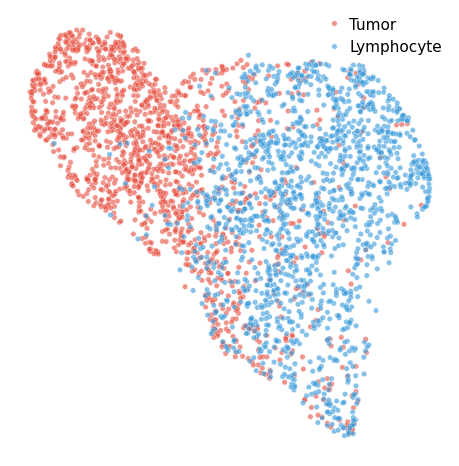

In [9]:
def style_pca_axis(ax, show_arrows=False):
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    if show_arrows:

        ax.annotate(
            '',
            xy=(0.25, 0.05),
            xytext=(0.05, 0.05),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black'))

        ax.annotate(
            '',
            xy=(0.05, 0.25),
            xytext=(0.05, 0.05),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black'))

        ax.text(0.26, 0.045, 'UMAP1', transform=ax.transAxes,
                ha='left', va='center', fontsize=10)
        ax.text(0.045, 0.26, 'UMAP2', transform=ax.transAxes,
                ha='center', va='bottom', fontsize=10)

from umap import UMAP

max_per_class = 1500
idx = []
rng = np.random.default_rng(42)
for cls in ["Tumor", "Lymphocyte"]:
    gi = np.where(y_final_cells.values == cls)[0]
    take = min(len(gi), max_per_class)
    idx.extend(rng.choice(gi, size=take, replace=False))
idx = np.array(idx)

n_umap_features = 5
X_sub = X_scaled_cells[idx, :n_umap_features]
print(f"Using top {n_umap_features} features for UMAP")
lab_sub = y_final_cells.values[idx]

print("Running UMAP...")
emb = UMAP(n_neighbors=30, min_dist=0.3, random_state=42).fit_transform(X_sub)

umap_df = pd.DataFrame(emb, columns=["UMAP1", "UMAP2"])
umap_df["Cell Type"] = lab_sub

fig, ax = plt.subplots(figsize=(5, 5))
colors = {"Tumor": "#E74C3C", "Lymphocyte": "#3498DB"}
sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="Cell Type", 
                s=15, alpha=0.6, palette=colors, ax=ax)
ax.legend(title="", fontsize=11, title_fontsize=12, loc='upper right')

ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
ax.set_axis_off()

out_umap = os.path.join(output_dir, "puma_umap_tumor_lymphocyte.png")
fig.savefig(out_umap, dpi=300, bbox_inches="tight")
print(f"Saved: {out_umap}")
plt.show()


## Visualization


In [10]:
import json
from PIL import Image
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

puma_data_dir = "/Users/tamara/Desktop/PyRadiomics/QuRad/example_data/puma_subset"

tile_ids_to_show = ['001', '005', '009']

def load_puma_tile_and_annotations(tile_id, data_dir):
    """Load PUMA tile image and nuclei annotations with object IDs."""
    img_path = os.path.join(data_dir, f"training_set_primary_roi_{tile_id}.tif")
    geojson_path = os.path.join(data_dir, f"training_set_primary_roi_{tile_id}_nuclei.geojson")
    
    if not os.path.exists(img_path) or not os.path.exists(geojson_path):
        return None, None
    
    img = np.array(Image.open(img_path))
    
    with open(geojson_path, 'r') as f:
        geojson = json.load(f)
    
    nuclei = []
    for feature in geojson.get('features', []):
        props = feature.get('properties', {})
        geom = feature.get('geometry', {})
        obj_id = feature.get('id', None)  # Get object ID from GeoJSON
        
        class_info = props.get('classification', {})
        if isinstance(class_info, dict):
            class_name = class_info.get('name', 'Unknown')
        else:
            class_name = str(class_info)
        
        class_lower = class_name.lower()
        if 'tumor' in class_lower:
            cell_type = 'Tumor'
        elif 'lymphocyte' in class_lower:
            cell_type = 'Lymphocyte'
        else:
            cell_type = 'Other'
        
        if geom.get('type') == 'Polygon':
            coords = geom.get('coordinates', [[]])[0]
            nuclei.append({
                'coords': np.array(coords),
                'class': cell_type,
                'obj_id': obj_id
            })
    
    return img, nuclei

available_tiles = []
for tid in ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']:
    img_path = os.path.join(puma_data_dir, f"training_set_primary_roi_{tid}.tif")
    if os.path.exists(img_path):
        available_tiles.append(tid)

print(f"Available tiles: {available_tiles}")
tile_ids_to_show = [available_tiles[i] for i in (0, 3, 5)]
print(f"Using tiles: {tile_ids_to_show}")


Available tiles: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']
Using tiles: ['001', '004', '006']


Built centroid lookup for 20 tiles
Tile 001: 404 matched, 1 unmatched
Tile 004: 215 matched, 0 unmatched
Tile 006: 155 matched, 1 unmatched
Saved: /Users/tamara/Desktop/PyRadiomics/QuRad/article_figures/figure1_puma_cell_classification.png


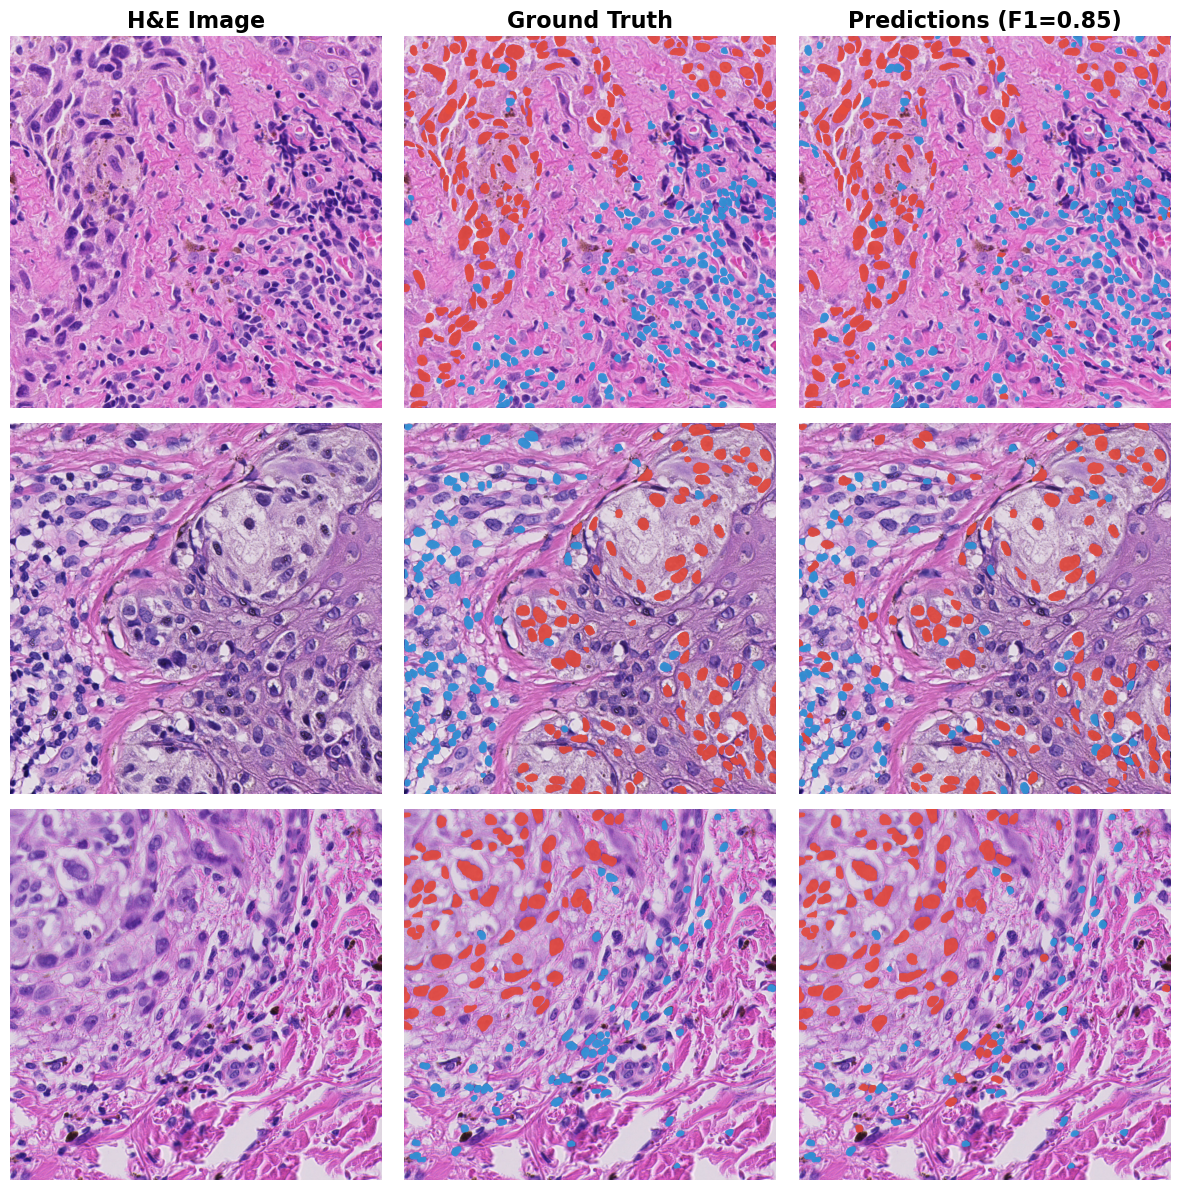

In [11]:
# --- Figure 1: Create the visualization with REAL predictions ---
# Build centroid-based prediction lookup from radiomics data

# Create lookup: (tile_id, centroid_x, centroid_y) -> predicted_class
# Use a spatial matching approach with tolerance

from scipy.spatial import cKDTree

def build_centroid_lookup(rad_cells_filtered, pred_rf_cells):
    """Build a dict of KDTrees for centroid matching, one per tile."""
    lookup = {}
    for tile_id in rad_cells_filtered['tile_id'].unique():
        mask = rad_cells_filtered['tile_id'] == tile_id
        tile_data = rad_cells_filtered[mask]
        coords = tile_data[['Centroid_X', 'Centroid_Y']].values
        preds = pred_rf_cells[mask.values]
        if len(coords) > 0:
            tree = cKDTree(coords)
            lookup[tile_id] = {'tree': tree, 'preds': preds, 'coords': coords}
    return lookup

centroid_lookup = build_centroid_lookup(rad_cells_filtered, pred_rf_cells)
print(f"Built centroid lookup for {len(centroid_lookup)} tiles")

# --- Visualization ---
fig, axes = plt.subplots(len(tile_ids_to_show), 3, figsize=(12, 4*len(tile_ids_to_show)))

colors = {'Tumor': '#E74C3C', 'Lymphocyte': '#3498DB', 'Other': '#95A5A6'}

for row, tile_id in enumerate(tile_ids_to_show):
    img, nuclei = load_puma_tile_and_annotations(tile_id, puma_data_dir)
    
    if img is None:
        print(f"Could not load tile {tile_id}")
        continue
    
    tile_id_int = int(tile_id)
    nuclei = [n for n in nuclei if n['class'] in ['Tumor', 'Lymphocyte']]
    
    # Column 1: Original image
    ax = axes[row, 0] if len(tile_ids_to_show) > 1 else axes[0]
    ax.imshow(img)
    if row == 0:
        ax.set_title('H&E Image', fontsize=16, fontweight='bold')
    ax.axis('off')
    
    # Column 2: Ground Truth
    ax = axes[row, 1] if len(tile_ids_to_show) > 1 else axes[1]
    ax.imshow(img)
    for nuc in nuclei:
        coords = nuc['coords']
        color = colors[nuc['class']]
        if len(coords) >= 3:
            polygon = MplPolygon(coords, fill=True, facecolor=color, edgecolor=color, alpha=0.9, linewidth=0.5)
            ax.add_patch(polygon)
    if row == 0:
        ax.set_title('Ground Truth', fontsize=16, fontweight='bold')
    ax.axis('off')
    
    # Column 3: Real Predictions (matched by centroid)
    ax = axes[row, 2] if len(tile_ids_to_show) > 1 else axes[2]
    ax.imshow(img)
    
    matched = 0
    unmatched = 0
    
    if tile_id_int in centroid_lookup:
        tree = centroid_lookup[tile_id_int]['tree']
        preds = centroid_lookup[tile_id_int]['preds']
        
        for nuc in nuclei:
            coords = nuc['coords']
            # Calculate centroid from polygon
            centroid_x = np.mean(coords[:, 0])
            centroid_y = np.mean(coords[:, 1])
            
            # Find nearest radiomics centroid
            dist, idx = tree.query([centroid_x, centroid_y])
            
            if dist < 5:  # tolerance of 5 pixels
                pred_class = preds[idx]
                matched += 1
            else:
                pred_class = nuc['class']  # fallback to ground truth
                unmatched += 1
            
            color = colors[pred_class]
            if len(coords) >= 3:
                polygon = MplPolygon(coords, fill=True, facecolor=color, edgecolor=color, alpha=0.9, linewidth=0.5)
                ax.add_patch(polygon)
    else:
        print(f"  No radiomics data for tile {tile_id_int}")
        unmatched = len(nuclei)
    
    print(f"Tile {tile_id}: {matched} matched, {unmatched} unmatched")
    
    if row == 0:
        ax.set_title(f'Predictions (F1={f1_rf_cells:.2f})', fontsize=16, fontweight='bold')
    ax.axis('off')

if len(tile_ids_to_show) > 1:
    for row, tid in enumerate(tile_ids_to_show):
        axes[row, 0].set_ylabel(f'ROI {tid}', fontsize=12, rotation=0, labelpad=40, va='center')

plt.tight_layout()
out_fig1 = os.path.join(output_dir, 'figure1_puma_cell_classification.png')
fig.savefig(out_fig1, dpi=300, bbox_inches='tight')
print(f"Saved: {out_fig1}")
plt.show()